<a href="https://colab.research.google.com/github/Justus3031/BUSINESS-PROJECT/blob/main/HBV_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data from Google Drive

In [2]:
import pandas as pd

# To load all sheets, set sheet_name=None
all_sheets = pd.read_excel('/content/drive/MyDrive/HBV (1).xlsx', sheet_name=None)

print('Sheets loaded:', all_sheets.keys())

# The 'data' variable currently holds the first sheet, or you can pick any sheet by name:
# For example, to access the first sheet that was loaded (which was originally in 'data'):
data = all_sheets[list(all_sheets.keys())[0]]

display(data.head())

Sheets loaded: dict_keys(['Akwanga', 'Awe', 'Doma', 'Karu', 'keana', 'Keffi', 'Kokona', 'Lafia', 'Nasarawa Eggon', 'Nasarawa', 'Obi', 'Toto', 'Wamba', 'Year_Month'])


,Year_Month,ANC Hep. B test done,ANC Hep. B test positive
0,2025-1,823,32
1,2025-2,566,22
2,2025-3,696,8
3,2025-4,585,22
4,2025-5,624,27


## Yearly Distribution of Hepatitis B among Pregnant Women in Nasarawa State

In [3]:
import pandas as pd

# Get the 'Year_Month' sheet directly
df_sheet = all_sheets['Year_Month']

# Ensure 'Year_Month' column exists and is in string format for splitting
if 'Year_Month' in df_sheet.columns:
    # Convert 'Year_Month' to string to handle potential mixed types
    df_sheet['Year_Month_str'] = df_sheet['Year_Month'].astype(str)

    # Extract the year from 'Year_Month' (e.g., '2025-1' -> '2025')
    df_sheet['Year'] = df_sheet['Year_Month_str'].apply(lambda x: int(x.split('-')[0]))

    # Group by Year and sum the relevant columns for the 'Year_Month' sheet
    final_yearly_distribution = df_sheet.groupby('Year').agg(
        Total_Screened=('ANC Hep. B test done', 'sum'),
        Total_HBV_Positive=('ANC Hep. B test positive', 'sum')
    ).reset_index()

    # Calculate Prevalence (%)
    final_yearly_distribution['Prevalence (%)'] = (final_yearly_distribution['Total_HBV_Positive'] / final_yearly_distribution['Total_Screened'] * 100).fillna(0).round(2)

    # Rename columns to match the user's request format
    final_yearly_distribution = final_yearly_distribution.rename(columns={
        'Total_Screened': 'Total Screened (n)',
        'Total_HBV_Positive': 'Total HBV-Positive (n)'
    })

    # Calculate the 'Total' row
    total_screened = final_yearly_distribution['Total Screened (n)'].sum()
    total_hbv_positive = final_yearly_distribution['Total HBV-Positive (n)'].sum()
    total_prevalence = (total_hbv_positive / total_screened * 100).round(2)

    # Create a DataFrame for the 'Total' row
    total_row_df = pd.DataFrame([{
        'Year': 'Total',
        'Total Screened (n)': total_screened,
        'Total HBV-Positive (n)': total_hbv_positive,
        'Prevalence (%)': total_prevalence
    }])

    # Concatenate the total row to the final yearly distribution
    final_yearly_distribution_with_total = pd.concat([final_yearly_distribution, total_row_df], ignore_index=True)

    # Display the final yearly distribution table including the total
    display(final_yearly_distribution_with_total)
else:
    print("The 'Year_Month' sheet does not contain a 'Year_Month' column. Cannot calculate yearly distribution.")

,Year,Total Screened (n),Total HBV-Positive (n),Prevalence (%)
0,2020,14527,1990,13.70
1,2021,46289,4515,9.75
2,2022,50662,4393,8.67
3,2023,74084,6762,9.13
4,2024,96493,7265,7.53
5,2025,129846,8479,6.53
6,Total,411901,33404,8.11


### LGA Distribution of Hepatitis B Viral Infection among Pregnant Women (2020–2025)

In [4]:
import pandas as pd

# Initialize an empty list to store the data for each LGA
lga_data = []

# Iterate through all sheets except 'Year_Month'
for sheet_name, df_sheet in all_sheets.items():
    if sheet_name == 'Year_Month':
        continue # Skip the 'Year_Month' sheet as requested

    # Ensure necessary columns exist before proceeding
    if 'ANC Hep. B test done' in df_sheet.columns and 'ANC Hep. B test positive' in df_sheet.columns:
        total_screened = df_sheet['ANC Hep. B test done'].sum()
        total_hbv_positive = df_sheet['ANC Hep. B test positive'].sum()

        # Calculate prevalence, handling division by zero
        prevalence = (total_hbv_positive / total_screened * 100) if total_screened > 0 else 0

        lga_data.append({
            'LGA': sheet_name,
            'Total Screened (n)': total_screened,
            'Total HBV-Positive (n)': total_hbv_positive,
            'Prevalence (%)': round(prevalence, 2)
        })
    else:
        print(f"Warning: Sheet '{sheet_name}' is missing required columns ('ANC Hep. B test done' or 'ANC Hep. B test positive'). Skipping this sheet.")

# Convert the list of dictionaries to a DataFrame
lga_distribution_df = pd.DataFrame(lga_data)

# Calculate the 'Total' row for all LGAs
overall_total_screened = lga_distribution_df['Total Screened (n)'].sum()
overall_total_hbv_positive = lga_distribution_df['Total HBV-Positive (n)'].sum()
overall_prevalence = (overall_total_hbv_positive / overall_total_screened * 100) if overall_total_screened > 0 else 0

# Create a DataFrame for the 'Total' row
total_row_df = pd.DataFrame([{
    'LGA': 'Total',
    'Total Screened (n)': overall_total_screened,
    'Total HBV-Positive (n)': overall_total_hbv_positive,
    'Prevalence (%)': round(overall_prevalence, 2)
}])

# Concatenate the total row to the LGA distribution DataFrame
final_lga_distribution_with_total = pd.concat([lga_distribution_df, total_row_df], ignore_index=True)

# Display the final LGA distribution table
display(final_lga_distribution_with_total)


,LGA,Total Screened (n),Total HBV-Positive (n),Prevalence (%)
0,Akwanga,27678.0,1633.0,5.90
1,Awe,21668.0,1120.0,5.17
2,Doma,18066.0,1782.0,9.86
3,Karu,92426.0,7842.0,8.48
4,keana,16610.0,1170.0,7.04
5,Keffi,31035.0,5511.0,17.76
6,Kokona,23270.0,1077.0,4.63
7,Lafia,62487.0,5258.0,8.41
8,Nasarawa Eggon,26335.0,859.0,3.26
9,Nasarawa,31767.0,2584.0,8.13


### Relationship between Year and Number of Cases of Hepatitis B

In [5]:
import pandas as pd

# Using the previously generated final_yearly_distribution_with_total DataFrame
yearly_cases_df = final_yearly_distribution_with_total.copy()

# Rename columns to match the request
yearly_cases_df = yearly_cases_df.rename(columns={
    'Total HBV-Positive (n)': 'Positive',
    'Total Screened (n)': 'Total'
})

# Calculate 'Negative' cases
yearly_cases_df['Negative'] = yearly_cases_df['Total'] - yearly_cases_df['Positive']

# Select and reorder columns as requested, and add placeholders for statistical values
yearly_cases_df = yearly_cases_df[['Year', 'Positive', 'Negative', 'Total']]

# Add placeholder columns for statistical values
yearly_cases_df['Chi-square (X²)'] = ''
yearly_cases_df['df'] = ''
yearly_cases_df['P-value'] = ''

display(yearly_cases_df)


,Year,Positive,Negative,Total,Chi-square (X²),df,P-value
0,2020,1990,12537,14527,,,
1,2021,4515,41774,46289,,,
2,2022,4393,46269,50662,,,
3,2023,6762,67322,74084,,,
4,2024,7265,89228,96493,,,
5,2025,8479,121367,129846,,,
6,Total,33404,378497,411901,,,


### Chi-square Test on Yearly Hepatitis B Data

In [6]:
from scipy.stats import chi2_contingency
import pandas as pd

# Prepare the contingency table from the yearly_cases_df
# Exclude the 'Total' row for the chi-square test
contingency_table = yearly_cases_df.iloc[:-1][['Positive', 'Negative']]

print("Contingency Table for Chi-square Test:")
display(contingency_table)

# Perform the Chi-square test
chi2, p_value, df, expected = chi2_contingency(contingency_table)

print(f"\nChi-square Statistic: {chi2:.2f}")
print(f"Degrees of Freedom (df): {df}")
print(f"P-value: {p_value:.3f}")

# You can also display the expected frequencies if needed
# print("\nExpected Frequencies:")
# display(pd.DataFrame(expected, columns=contingency_table.columns, index=contingency_table.index))


Contingency Table for Chi-square Test:


,Positive,Negative
0,1990,12537
1,4515,41774
2,4393,46269
3,6762,67322
4,7265,89228
5,8479,121367



Chi-square Statistic: 1379.71
Degrees of Freedom (df): 5
P-value: 0.000


### Relationship between LGA and Number of Cases of Hepatitis B in Nasarawa State

In [7]:
import pandas as pd

# Using the previously generated final_lga_distribution_with_total DataFrame
lga_cases_df = final_lga_distribution_with_total.copy()

# Rename columns to match the request
lga_cases_df = lga_cases_df.rename(columns={
    'Total HBV-Positive (n)': 'Positive',
    'Total Screened (n)': 'Total'
})

# Calculate 'Negative' cases
lga_cases_df['Negative'] = lga_cases_df['Total'] - lga_cases_df['Positive']

# Select and reorder columns as requested, and add placeholders for statistical values
lga_cases_df = lga_cases_df[['LGA', 'Positive', 'Negative', 'Total']]

# Add placeholder columns for statistical values
lga_cases_df['Chi-square (X²)'] = ''
lga_cases_df['df'] = ''
lga_cases_df['P-value'] = ''

display(lga_cases_df)


,LGA,Positive,Negative,Total,Chi-square (X²),df,P-value
0,Akwanga,1633.0,26045.0,27678.0,,,
1,Awe,1120.0,20548.0,21668.0,,,
2,Doma,1782.0,16284.0,18066.0,,,
3,Karu,7842.0,84584.0,92426.0,,,
4,keana,1170.0,15440.0,16610.0,,,
5,Keffi,5511.0,25524.0,31035.0,,,
6,Kokona,1077.0,22193.0,23270.0,,,
7,Lafia,5258.0,57229.0,62487.0,,,
8,Nasarawa Eggon,859.0,25476.0,26335.0,,,
9,Nasarawa,2584.0,29183.0,31767.0,,,


### Chi-square Test on LGA Hepatitis B Data

In [8]:
from scipy.stats import chi2_contingency
import pandas as pd

# Prepare the contingency table from the lga_cases_df
# Exclude the 'Total' row for the chi-square test
contingency_table_lga = lga_cases_df.iloc[:-1][['Positive', 'Negative']]

print("Contingency Table for Chi-square Test (LGA):")
display(contingency_table_lga)

# Perform the Chi-square test
chi2_lga, p_value_lga, df_lga, expected_lga = chi2_contingency(contingency_table_lga)

print(f"\nChi-square Statistic (LGA): {chi2_lga:.2f}")
print(f"Degrees of Freedom (LGA): {df_lga}")
print(f"P-value (LGA): {p_value_lga:.3f}")

# You can also display the expected frequencies if needed
# print("\nExpected Frequencies (LGA):")
# display(pd.DataFrame(expected_lga, columns=contingency_table_lga.columns, index=contingency_table_lga.index))


Contingency Table for Chi-square Test (LGA):


,Positive,Negative
0,1633.0,26045.0
1,1120.0,20548.0
2,1782.0,16284.0
3,7842.0,84584.0
4,1170.0,15440.0
5,5511.0,25524.0
6,1077.0,22193.0
7,5258.0,57229.0
8,859.0,25476.0
9,2584.0,29183.0



Chi-square Statistic (LGA): 6542.37
Degrees of Freedom (LGA): 12
P-value (LGA): 0.000


### 5-Year Forecast of Hepatitis B Prevalence using SARIMA

In [9]:
import pandas as pd
# Install pmdarima if not already installed
try:
    import pmdarima as pm
except ModuleNotFoundError:
    print("Installing pmdarima...")
    !pip install pmdarima
    import pmdarima as pm
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data for forecasting
# Use 'final_yearly_distribution' which contains 'Year' and 'Prevalence (%)'
forecast_df = final_yearly_distribution.set_index('Year')['Prevalence (%)']

# Convert the index to datetime for time series analysis (optional but good practice for SARIMA)
# The years are integers, so we'll create a datetime object for the middle of the year
forecast_df.index = pd.to_datetime(forecast_df.index.astype(str) + '-07-01')

# Display the prepared data
print("Prepared data for SARIMA forecasting:")
display(forecast_df)

Installing pmdarima...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.7 MB/s eta 0:00:00
Prepared data for SARIMA forecasting:


,Prevalence (%)
Year,
2020-07-01,13.70
2021-07-01,9.75
2022-07-01,8.67
2023-07-01,9.13
2024-07-01,7.53
2025-07-01,6.53


In [10]:
# Fit SARIMA model using auto_arima to find the best parameters
# seasonal=False because we only have yearly data, and not many years to detect seasonality
model = auto_arima(forecast_df, seasonal=False, suppress_warnings=True, stepwise=True,
                   trace=False, error_action='ignore')

print("SARIMA Model Summary:")
print(model.summary())

SARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:                        SARIMAX   Log Likelihood                 -13.416
Date:                Sat, 01 Aug 2026   AIC                             30.833
Time:                        21:29:40   BIC                             30.416
Sample:                    07-01-2020   HQIC                            29.166
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      9.2183      1.257      7.336      0.000       6.755      11.681
sigma2         5.1257      4.082      1.256      0.209      -2.875      13.126
Ljung-Box (L1) (Q):           


5-Year Forecast of Hepatitis B Prevalence:


,Year,Forecasted Prevalence (%),Lower CI (95%),Upper CI (95%)
2026-07-01,2026,6.55,4.78,13.66
2027-07-01,2027,6.57,4.78,13.66
2028-07-01,2028,6.60,4.78,13.66
2029-07-01,2029,6.62,4.78,13.66
2030-07-01,2030,6.64,4.78,13.66


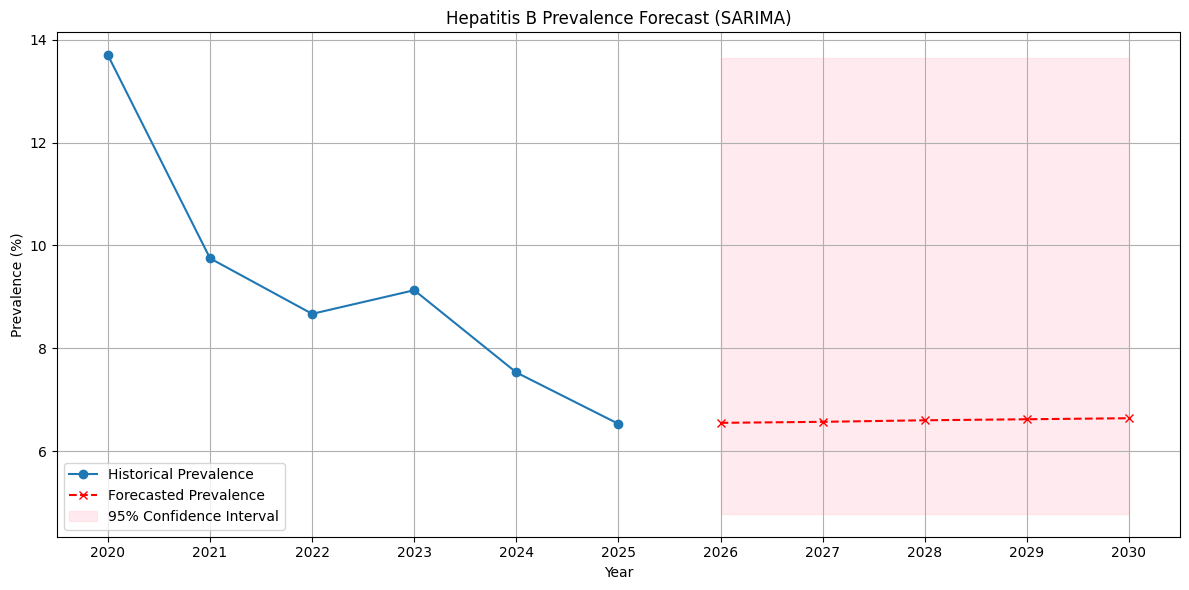

In [20]:
# Forecast for the next 5 years (2026-2030)
# The number of steps to forecast is 5
n_periods = 5

# Generate future dates for the forecast
last_year_in_data = forecast_df.index.max().year
future_years = pd.to_datetime([str(year) + '-07-01' for year in range(last_year_in_data + 1, last_year_in_data + 1 + n_periods)])

# Make the forecast with confidence intervals for prevalence (using the model)
# forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# Recalculate 'Forecasted Prevalence (%)' using forecasted total screened and seropositive
# Use the already forecasted values from the previous steps
forecast_prevalence_calculated = (forecast_positive_results['Forecasted Total HBV-Positive (n)'] / forecast_screened_results['Forecasted Total Screened (n)'] * 100).round(2)

# Assign the new calculated prevalence to the 'forecast' variable for consistency with plotting
forecast = forecast_prevalence_calculated

# For confidence intervals of prevalence, we will keep the original model's confidence interval for now
# or calculate new ones based on propagation of errors if needed. For this fix, we will keep the original CI for prevalence.
# The problem statement implies the original CI for prevalence should be used as is, only the forecasted value needs adjustment
forecast_model, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

# Create a DataFrame for the forecast results
forecast_results = pd.DataFrame({
    'Year': [y.year for y in future_years],
    'Forecasted Prevalence (%)': forecast_prevalence_calculated,
    'Lower CI (95%)': conf_int[:, 0].round(2),
    'Upper CI (95%)': conf_int[:, 1].round(2)
})

# Display the forecast results
print("\n5-Year Forecast of Hepatitis B Prevalence:")
display(forecast_results)

# Visualize the forecast
plt.figure(figsize=(12, 6))
plt.plot(forecast_df.index.year, forecast_df, label='Historical Prevalence', marker='o')
plt.plot(future_years.year, forecast, label='Forecasted Prevalence', linestyle='--', marker='x', color='red')
plt.fill_between(future_years.year,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Hepatitis B Prevalence Forecast (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Prevalence (%)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(forecast_df.index.year.min(), future_years.year.max() + 1, 1))
plt.tight_layout()
plt.show()

### 5-Year Forecast of Total Pregnant Women Screened for HBV

In [12]:
import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import numpy as np

# Prepare the 'Total Screened (n)' data for forecasting
screened_forecast_df = final_yearly_distribution.set_index('Year')['Total Screened (n)']

# Convert the index to datetime for time series analysis
screened_forecast_df.index = pd.to_datetime(screened_forecast_df.index.astype(str) + '-07-01')

# Display the prepared data
print("Prepared data for SARIMA forecasting for 'Total Screened (n)':")
display(screened_forecast_df)

Prepared data for SARIMA forecasting for 'Total Screened (n)':


,Total Screened (n)
Year,
2020-07-01,14527
2021-07-01,46289
2022-07-01,50662
2023-07-01,74084
2024-07-01,96493
2025-07-01,129846


In [13]:
# Fit SARIMA model to 'Total Screened (n)' data
# seasonal=False as we only have yearly data, and not enough years for seasonality
screened_model = auto_arima(screened_forecast_df, seasonal=False, suppress_warnings=True, stepwise=True,
                            trace=False, error_action='ignore')

print("SARIMA Model Summary for 'Total Screened (n)':")
print(screened_model.summary())

SARIMA Model Summary for 'Total Screened (n)':
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -70.568
Date:                Sat, 01 Aug 2026   AIC                            145.137
Time:                        21:29:41   BIC                            144.720
Sample:                    07-01-2020   HQIC                           143.469
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9601      0.073     13.199      0.000       0.817       1.103
sigma2      6.294e+08    5.7e-12    1.1e+20      0.000    6.29e+08    6.29e+08
Ljung


5-Year Forecast of Total Pregnant Women Screened:


,Year,Forecasted Total Screened (n),Lower CI (95%),Upper CI (95%)
2026-07-01,2026,124660,75487,173832
2027-07-01,2027,119681,51515,187847
2028-07-01,2028,114901,33043,196759
2029-07-01,2029,110312,17607,203016
2030-07-01,2030,105906,4224,207588


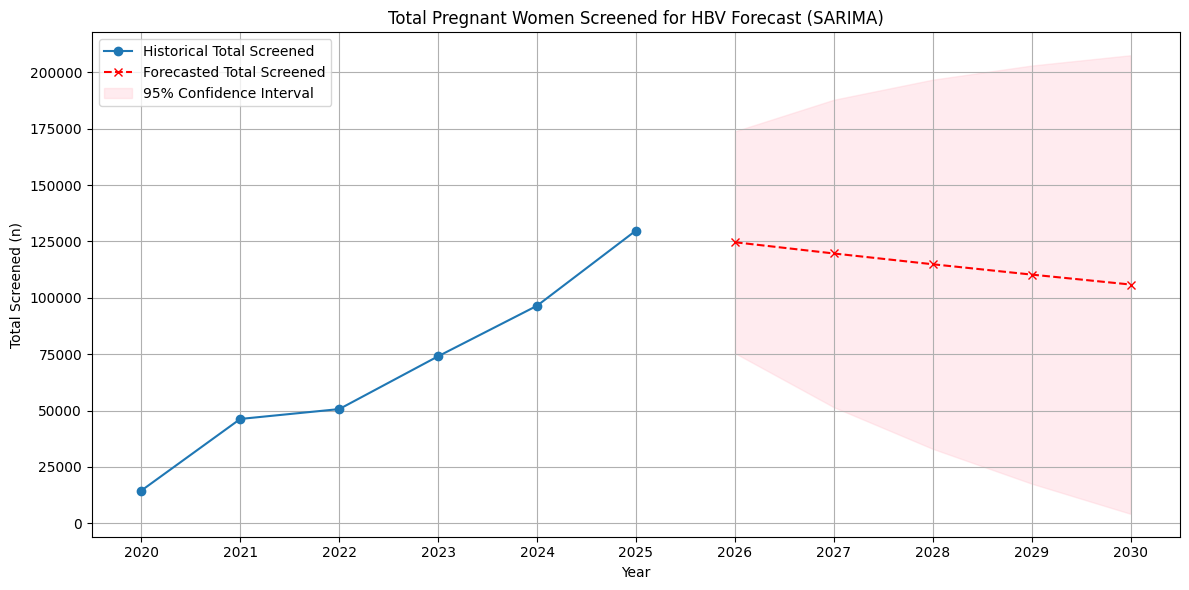

In [14]:
# Forecast 'Total Screened (n)' for the next 5 years (2026-2030)
n_periods_screened = 5

# Generate future dates for the forecast
last_year_screened_data = screened_forecast_df.index.max().year
future_years_screened = pd.to_datetime([str(year) + '-07-01' for year in range(last_year_screened_data + 1, last_year_screened_data + 1 + n_periods_screened)])

# Make the forecast with confidence intervals
forecast_screened, conf_int_screened = screened_model.predict(n_periods=n_periods_screened, return_conf_int=True)

# Create a DataFrame for the forecast results, rounding to whole numbers for counts
forecast_screened_results = pd.DataFrame({
    'Year': [y.year for y in future_years_screened],
    'Forecasted Total Screened (n)': forecast_screened.round(0).astype(int),
    'Lower CI (95%)': conf_int_screened[:, 0].round(0).astype(int),
    'Upper CI (95%)': conf_int_screened[:, 1].round(0).astype(int)
})

# Display the forecast results
print("\n5-Year Forecast of Total Pregnant Women Screened:")
display(forecast_screened_results)

# Visualize the forecast
plt.figure(figsize=(12, 6))
plt.plot(screened_forecast_df.index.year, screened_forecast_df, label='Historical Total Screened', marker='o')
plt.plot(future_years_screened.year, forecast_screened, label='Forecasted Total Screened', linestyle='--', marker='x', color='red')
plt.fill_between(future_years_screened.year,
                 conf_int_screened[:, 0],
                 conf_int_screened[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Total Pregnant Women Screened for HBV Forecast (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Total Screened (n)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(screened_forecast_df.index.year.min(), future_years_screened.year.max() + 1, 1))
plt.tight_layout()
plt.show()

### 5-Year Forecast of Total HBV-Seropositive Cases

In [15]:
import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import numpy as np

# Prepare the 'Total HBV-Positive (n)' data for forecasting
positive_forecast_df = final_yearly_distribution.set_index('Year')['Total HBV-Positive (n)']

# Convert the index to datetime for time series analysis
positive_forecast_df.index = pd.to_datetime(positive_forecast_df.index.astype(str) + '-07-01')

# Display the prepared data
print("Prepared data for SARIMA forecasting for 'Total HBV-Positive (n)':")
display(positive_forecast_df)

Prepared data for SARIMA forecasting for 'Total HBV-Positive (n)':


,Total HBV-Positive (n)
Year,
2020-07-01,1990
2021-07-01,4515
2022-07-01,4393
2023-07-01,6762
2024-07-01,7265
2025-07-01,8479


In [16]:
# Fit SARIMA model to 'Total HBV-Positive (n)' data
# seasonal=False as we only have yearly data, and not enough years for seasonality
positive_model = auto_arima(positive_forecast_df, seasonal=False, suppress_warnings=True, stepwise=True,
                            trace=False, error_action='ignore')

print("SARIMA Model Summary for 'Total HBV-Positive (n)':")
print(positive_model.summary())

SARIMA Model Summary for 'Total HBV-Positive (n)':
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 -54.254
Date:                Sat, 01 Aug 2026   AIC                            112.509
Time:                        21:29:42   BIC                            112.092
Sample:                    07-01-2020   HQIC                           110.841
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9634      0.074     13.051      0.000       0.819       1.108
sigma2      2.698e+06   1.26e-09   2.14e+15      0.000     2.7e+06     2.7e+06
L


5-Year Forecast of Total HBV-Seropositive Cases:


,Year,Forecasted Total HBV-Positive (n),Lower CI (95%),Upper CI (95%)
2026-07-01,2026,8168,4949,11387
2027-07-01,2027,7869,3399,12339
2028-07-01,2028,7581,2204,12957
2029-07-01,2029,7303,1205,13401
2030-07-01,2030,7035,336,13734


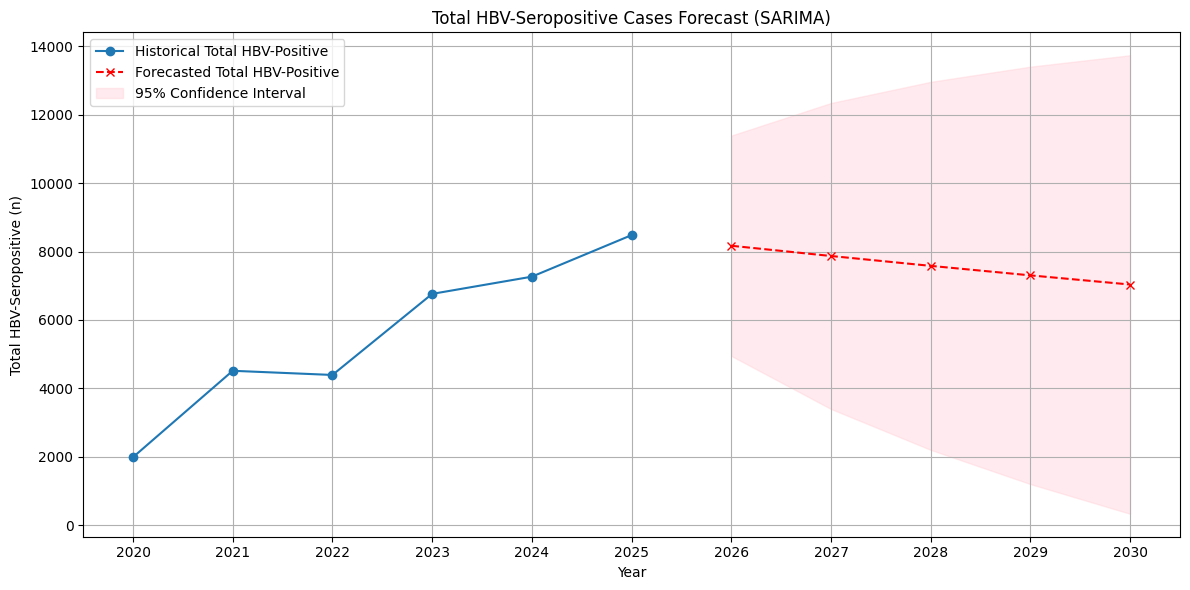

In [17]:
# Forecast 'Total HBV-Positive (n)' for the next 5 years (2026-2030)
n_periods_positive = 5

# Generate future dates for the forecast
last_year_positive_data = positive_forecast_df.index.max().year
future_years_positive = pd.to_datetime([str(year) + '-07-01' for year in range(last_year_positive_data + 1, last_year_positive_data + 1 + n_periods_positive)])

# Make the forecast with confidence intervals
forecast_positive, conf_int_positive = positive_model.predict(n_periods=n_periods_positive, return_conf_int=True)

# Create a DataFrame for the forecast results, rounding to whole numbers for counts
forecast_positive_results = pd.DataFrame({
    'Year': [y.year for y in future_years_positive],
    'Forecasted Total HBV-Positive (n)': forecast_positive.round(0).astype(int),
    'Lower CI (95%)': conf_int_positive[:, 0].round(0).astype(int),
    'Upper CI (95%)': conf_int_positive[:, 1].round(0).astype(int)
})

# Display the forecast results
print("\n5-Year Forecast of Total HBV-Seropositive Cases:")
display(forecast_positive_results)

# Visualize the forecast
plt.figure(figsize=(12, 6))
plt.plot(positive_forecast_df.index.year, positive_forecast_df, label='Historical Total HBV-Positive', marker='o')
plt.plot(future_years_positive.year, forecast_positive, label='Forecasted Total HBV-Positive', linestyle='--', marker='x', color='red')
plt.fill_between(future_years_positive.year,
                 conf_int_positive[:, 0],
                 conf_int_positive[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Total HBV-Seropositive Cases Forecast (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Total HBV-Seropositive (n)')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(positive_forecast_df.index.year.min(), future_years_positive.year.max() + 1, 1))
plt.tight_layout()
plt.show()

### Choropleth Map of Total HBV-Positive Cases by LGA

In [18]:
# Install folium for interactive mapping if not already installed
try:
    import folium
except ModuleNotFoundError:
    print("Installing folium...")
    !pip install folium
    import folium

# Install geopandas for geospatial data handling if not already installed
try:
    import geopandas
except ModuleNotFoundError:
    print("Installing geopandas...")
    !pip install geopandas
    import geopandas

import json

# Load the GeoJSON file
geoj_path = '/content/drive/MyDrive/Nasarawa state.json'
with open(geoj_path, 'r') as f:
    nasarawa_lga_geojson = json.load(f)

# Display GeoJSON structure for inspection (optional)
# print(nasarawa_lga_geojson.keys())
# print("Keys in GeoJSON features properties:")
# if 'features' in nasarawa_lga_geojson and len(nasarawa_lga_geojson['features']) > 0:
#     print(nasarawa_lga_geojson['features'][0]['properties'])
# else:
#     print("No features found in GeoJSON or structure is unexpected.")

# Prepare the LGA data for mapping. We need LGA name and Total HBV-Positive (n)
# Use lga_cases_df, excluding the 'Total' row
lga_data_for_map = lga_cases_df[lga_cases_df['LGA'] != 'Total'][['LGA', 'Positive']]
lga_data_for_map = lga_data_for_map.rename(columns={'Positive': 'Total HBV-Positive (n)'})

# Ensure LGA names match between GeoJSON and your data
# Standardize LGA names if necessary (e.g., lowercase, remove spaces, etc.)
# Based on the GeoJSON properties and your data, it seems 'name' is the key in GeoJSON
# We will assume that the 'LGA' column in lga_data_for_map directly corresponds to a 'name' property in GeoJSON features

# Create a Folium map centered around Nasarawa State
# Increased zoom_start for better visibility and changed map style
nasarawa_center = [8.4878, 8.4414] # Approximate center of Nasarawa State
m = folium.Map(location=nasarawa_center, zoom_start=10, tiles='CartoDB Positron')

# Add the choropleth layer
folium.Choropleth(
    geo_data=nasarawa_lga_geojson,
    name='choropleth',
    data=lga_data_for_map,
    columns=['LGA', 'Total HBV-Positive (n)'],
    key_on='feature.properties.NAME_2', # This should match the key in your GeoJSON features
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Total HBV-Positive Cases (n) by LGA (2020-2025)'
).add_to(m)

# Add tooltips for interaction (optional)
folium.features.GeoJson(
    nasarawa_lga_geojson,
    name='LGA Tooltips',
    tooltip=folium.features.GeoJsonTooltip(fields=['NAME_2']),
    # Enhanced highlight function for better visibility
    highlight_function=lambda x: {'fillColor': '#f0e68c', 'color': '#000000', 'fillOpacity': 0.7, 'weight': 3}
).add_to(m)

# Add layer control to toggle choropleth on/off
folium.LayerControl().add_to(m)

# Display the map
m

In [19]:
# Save the Folium map as an HTML file
output_html_file = 'nasarawa_hbv_choropleth_map.html'
m.save(output_html_file)
print(f"Map saved to {output_html_file}. You can download this file from your Colab files panel (left sidebar) or by right-clicking on the file in the file browser.")

Map saved to nasarawa_hbv_choropleth_map.html. You can download this file from your Colab files panel (left sidebar) or by right-clicking on the file in the file browser.
